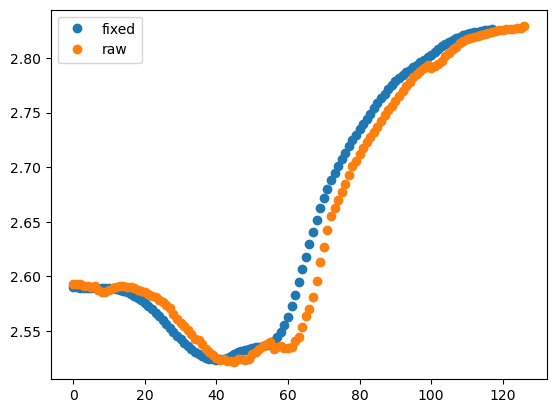

(127, 9)


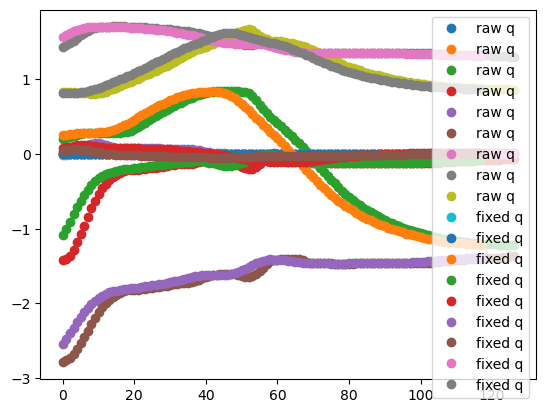

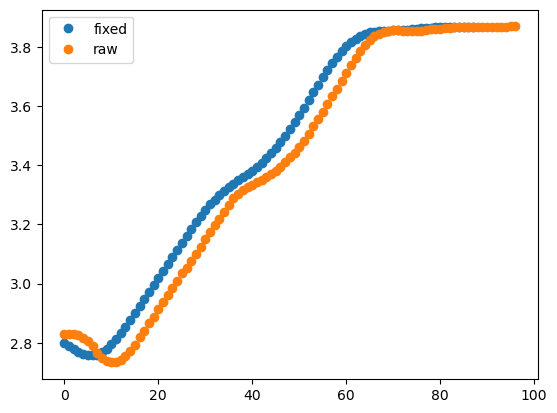

(97, 9)


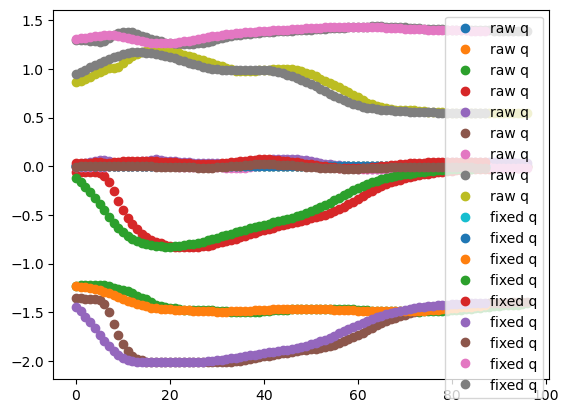

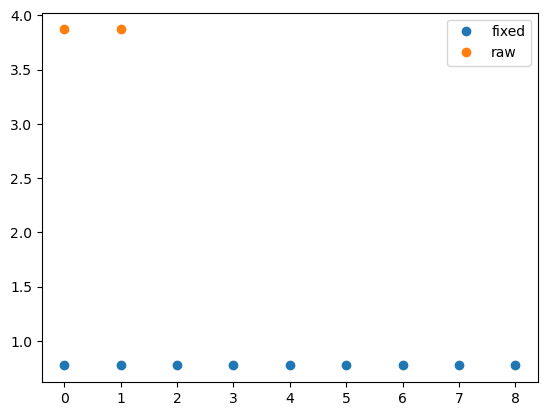

(2, 9)


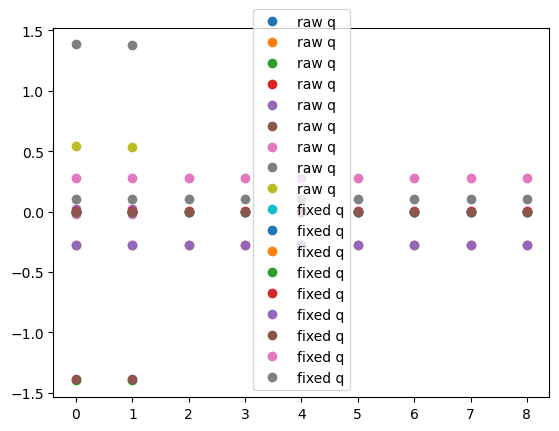

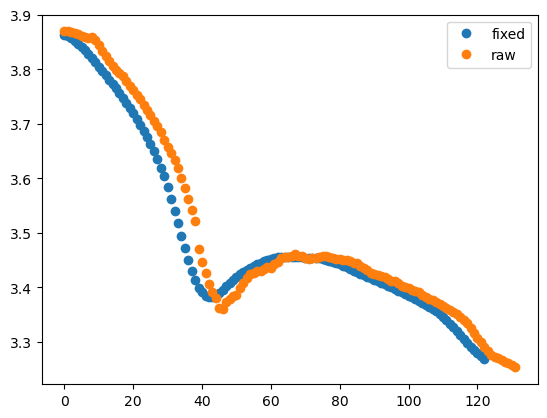

(132, 9)


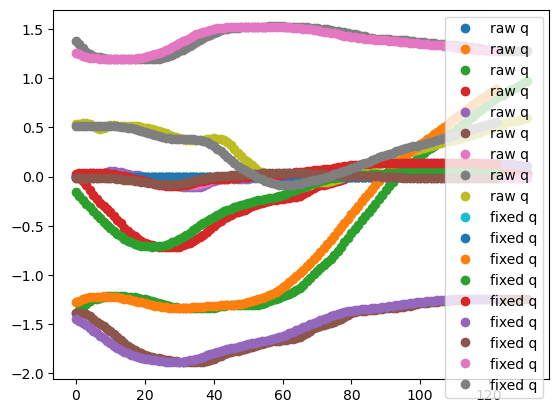

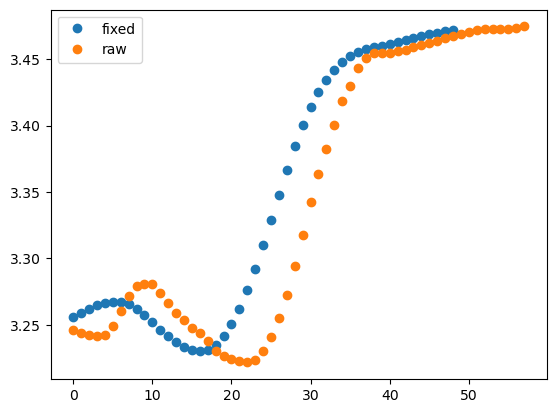

(58, 9)


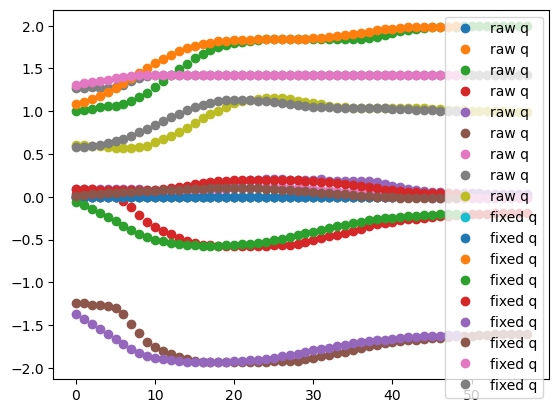

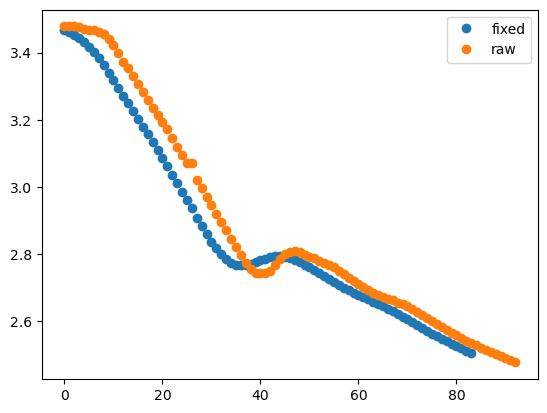

(93, 9)


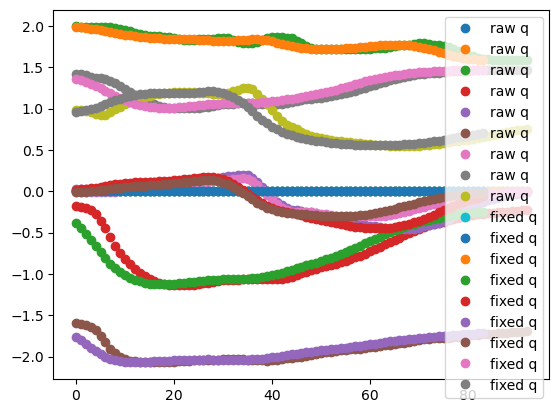

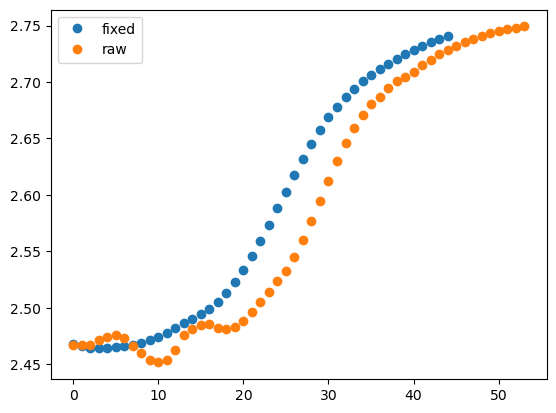

(54, 9)


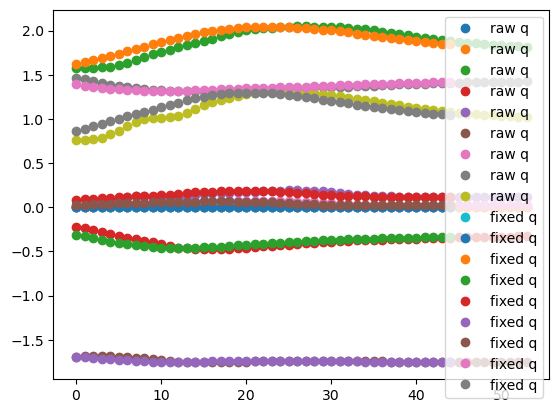

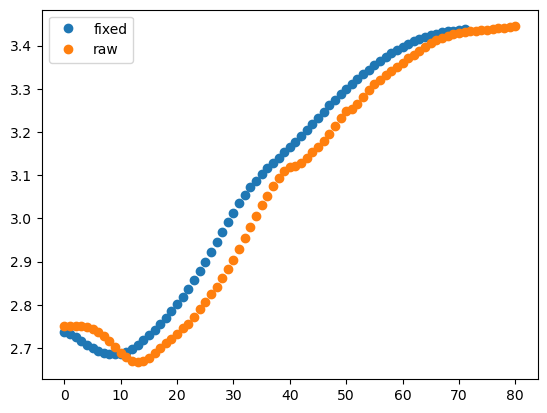

(81, 9)


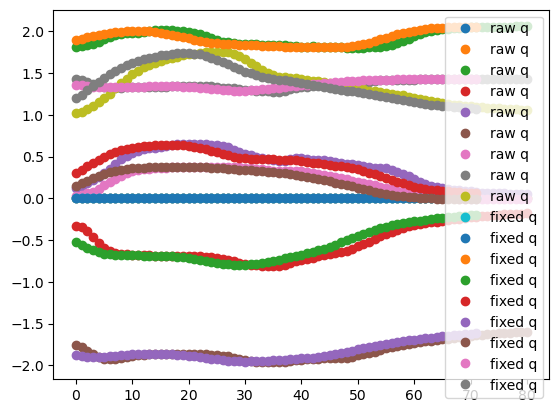

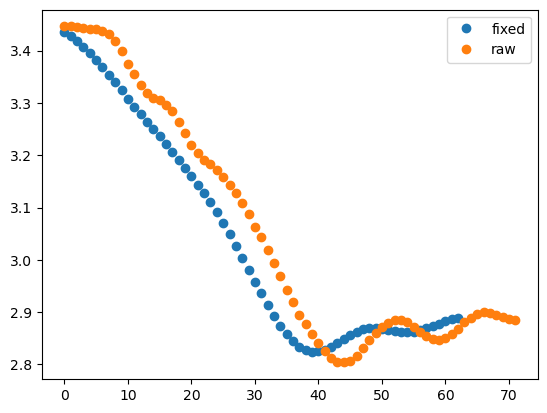

(72, 9)


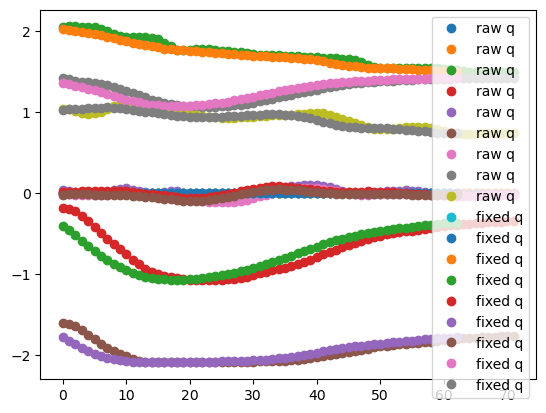

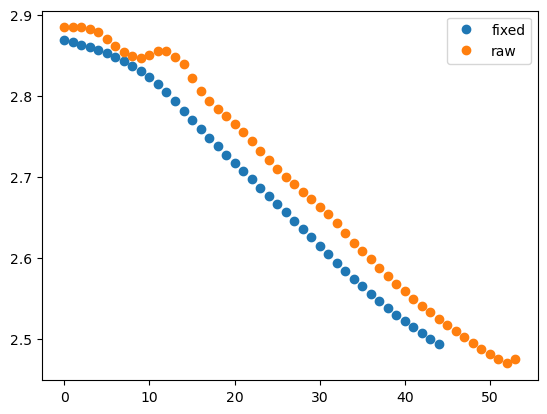

(54, 9)


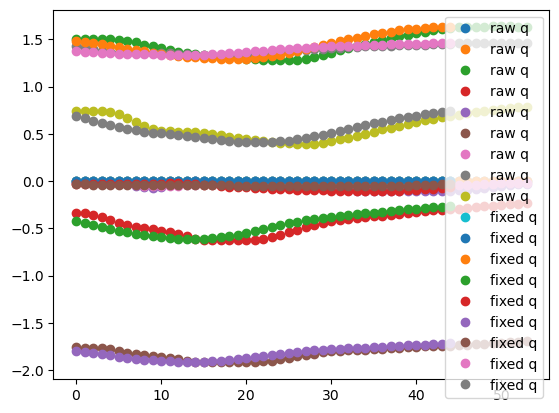

FileNotFoundError: [Errno 2] No such file or directory: '../../logs/real_robot/s12_points_05_speed_beta_5/exp_9_odom/data.npz'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import spatialmath as sm

exp_number = 0
for exp_number in range(0, 10):
    data = np.load(f"../../logs/real_robot/s12_higher_eta_2/exp_{exp_number}_fixed/data.npz",allow_pickle=True)

    base = data["base"]

    sm_base = [sm.SE3(x, check=False).norm() for x in base]
    filter_size = 10
    x = base[:,0,3]
    x_fix = np.convolve(base[:,0,3], np.ones(filter_size)/filter_size, mode='valid')
    y_fix = np.convolve(base[:,1,3], np.ones(filter_size)/filter_size, mode='valid')
    z = [b.rpy()[2] for b in sm_base]
    z_fix = np.convolve(z, np.ones(filter_size)/filter_size, mode='valid')

    fixed_base = [sm.SE3(x_fix[i], y_fix[i], 0) @ sm.SE3.Rz(z_fix[i]) for i in range(len(x_fix))]
    # repeat the first element for the 5 first elements
    fixed_base = [fixed_base[0]]* int(filter_size/2) + fixed_base
    # same in the end
    fixed_base = fixed_base + [fixed_base[-1]]* int(filter_size/2)



    plt.plot(x_fix[:], 'o', label="fixed")
    plt.plot(x[:], 'o',label = "raw")
    plt.legend()
    plt.show()
    
    # fix_q_also
    q = data["q"]
    print(q.shape)
    kernel = np.ones(filter_size)/filter_size
    # q_fixed = np.convolve(q, np.ones(filter_size)/filter_size, mode='valid')
    q_fixed = np.apply_along_axis(lambda x: np.convolve(x, kernel , mode='valid'), axis=0, arr=q)
    plt.plot(q, 'o', label="raw q")
    plt.plot(q_fixed, 'o', label="fixed q")
    plt.legend()
    plt.show()
    new_data = {**data, "fixed_base": fixed_base, "fixed_q": q_fixed}

    np.savez(f"../../logs/real_robot/s12_points_05_speed_beta_5/exp_{exp_number}_odom/data.npz", **new_data)
    